# Last.fm 360K — Data exploration

Explore the **lastfm-dataset-360K**: user–artist play counts and user profiles.

- **Plays:** `user_sha1`, `artist_mbid`, `artist_name`, `plays`
- **Profiles:** `user_sha1`, `gender`, `age`, `country`, `signup`

## 1. Setup and load data

In [2]:
import pandas as pd
from pathlib import Path

DATASET_DIR = Path("../dataset")
PLAYS_FILE = DATASET_DIR / "usersha1-artmbid-artname-plays.tsv"
PROFILE_FILE = DATASET_DIR / "usersha1-profile.tsv"

# Sample size for plays (full file is ~17.5M rows). Increase for more data.
NROWS = 500_000

plays = pd.read_csv(PLAYS_FILE, sep="\t", nrows=NROWS, header=None,
                   names=["user_sha1", "artist_mbid", "artist_name", "plays"])
profiles = pd.read_csv(PROFILE_FILE, sep="\t", header=None,
                       names=["user_sha1", "gender", "age", "country", "signup"])

print("Plays shape:", plays.shape)
print("Profiles shape:", profiles.shape)

Plays shape: (500000, 4)
Profiles shape: (359347, 5)


## 2. Plays — overview

In [3]:
plays.head(10)

,user_sha1,artist_mbid,artist_name,plays
0,00000c289a1829a808ac09c00daf10bc3c4e223b,3bd73256-3905-4f3a-97e2-8b341527f805,betty blowtorch,2137
1,00000c289a1829a808ac09c00daf10bc3c4e223b,f2fb0ff0-5679-42ec-a55c-15109ce6e320,die Ärzte,1099
2,00000c289a1829a808ac09c00daf10bc3c4e223b,b3ae82c2-e60b-4551-a76d-6620f1b456aa,melissa etheridge,897
3,00000c289a1829a808ac09c00daf10bc3c4e223b,3d6bbeb7-f90e-4d10-b440-e153c0d10b53,elvenking,717
4,00000c289a1829a808ac09c00daf10bc3c4e223b,bbd2ffd7-17f4-4506-8572-c1ea58c3f9a8,juliette & the licks,706
5,00000c289a1829a808ac09c00daf10bc3c4e223b,8bfac288-ccc5-448d-9573-c33ea2aa5c30,red hot chili peppers,691
6,00000c289a1829a808ac09c00daf10bc3c4e223b,6531c8b1-76ea-4141-b270-eb1ac5b41375,magica,545
7,00000c289a1829a808ac09c00daf10bc3c4e223b,21f3573f-10cf-44b3-aeaa-26cccd8448b5,the black dahlia murder,507
8,00000c289a1829a808ac09c00daf10bc3c4e223b,c5db90c4-580d-4f33-b364-fbaa5a3a58b5,the murmurs,424
9,00000c289a1829a808ac09c00daf10bc3c4e223b,0639533a-0402-40ba-b6e0-18b067198b73,lunachicks,403


In [4]:
plays.info()
plays.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   user_sha1    500000 non-null  str  
 1   artist_mbid  493553 non-null  str  
 2   artist_name  499997 non-null  str  
 3   plays        500000 non-null  int64
dtypes: int64(1), str(3)
memory usage: 15.3 MB


,plays
count,500000.000000
mean,214.531844
std,588.185202
min,1.000000
25%,34.000000
50%,94.000000
75%,223.000000
max,135392.000000


## 3. User profiles — overview

In [5]:
profiles.head(10)

,user_sha1,gender,age,country,signup
0,00000c289a1829a808ac09c00daf10bc3c4e223b,f,22.0,Germany,"Feb 1, 2007"
1,00001411dc427966b17297bf4d69e7e193135d89,f,NaN,Canada,"Dec 4, 2007"
2,00004d2ac9316e22dc007ab2243d6fcb239e707d,NaN,NaN,Germany,"Sep 1, 2006"
3,000063d3fe1cf2ba248b9e3c3f0334845a27a6bf,m,19.0,Mexico,"Apr 28, 2008"
4,00007a47085b9aab8af55f52ec8846ac479ac4fe,m,28.0,United States,"Jan 27, 2006"
5,0000c176103e538d5c9828e695fed4f7ae42dd01,m,20.0,United Kingdom,"Jan 14, 2006"
6,0000ee7dd906373efa37f4e1185bfe1e3f8695ae,m,17.0,Finland,"Nov 17, 2007"
7,0000ef373bbd0d89ce796abae961f2705e8c1faf,f,22.0,Poland,"May 23, 2007"
8,0000f687d4fe9c1ed49620fbc5ed5b0d7798ea20,f,24.0,Spain,"Nov 4, 2008"
9,0001399387da41d557219578fb08b12afa25ab67,m,NaN,Ukraine,"Aug 17, 2008"


In [6]:
profiles.info()
profiles.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 359347 entries, 0 to 359346
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_sha1  359347 non-null  str    
 1   gender     326572 non-null  str    
 2   age        284447 non-null  float64
 3   country    359347 non-null  str    
 4   signup     359347 non-null  str    
dtypes: float64(1), str(4)
memory usage: 13.7 MB


,user_sha1,gender,age,country,signup
count,359347,326572,284447.000000,359347,359347
unique,359347,2,NaN,239,2298
top,00000c289a1829a808ac09c00daf10bc3c4e223b,m,NaN,United States,"Jan 24, 2008"
freq,1,241642,NaN,67044,569
mean,NaN,NaN,25.098046,NaN,NaN
std,NaN,NaN,21.665742,NaN,NaN
min,NaN,NaN,-1337.000000,NaN,NaN
25%,NaN,NaN,20.000000,NaN,NaN
50%,NaN,NaN,23.000000,NaN,NaN
75%,NaN,NaN,28.000000,NaN,NaN


## 4. Top artists by total plays

In [7]:
top_artists = plays.groupby("artist_name", as_index=False).agg(plays=("plays", "sum")).sort_values("plays", ascending=False)
top_artists.head(20)

,artist_name,plays
48273,the beatles,904835
40509,radiohead,798125
11602,coldplay,466102
35273,muse,444435
39305,pink floyd,425050
33601,metallica,418201
30273,linkin park,410496
36474,nine inch nails,374149
40981,red hot chili peppers,352309
47235,system of a down,346543


## 5. Distribution of play counts

Matplotlib is building the font cache; this may take a moment.


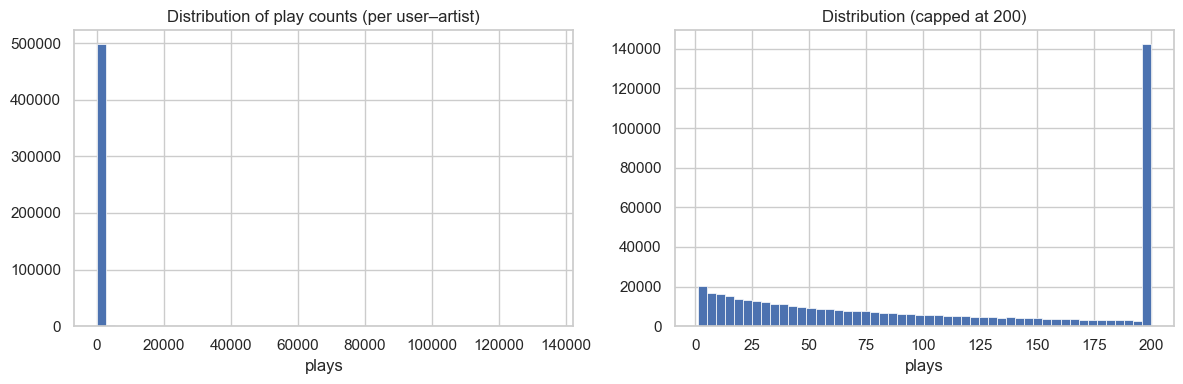

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plays["plays"].hist(bins=50, ax=axes[0], edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribution of play counts (per user–artist)")
axes[0].set_xlabel("plays")

plays["plays"].clip(upper=200).hist(bins=50, ax=axes[1], edgecolor="white", linewidth=0.5)
axes[1].set_title("Distribution (capped at 200)")
axes[1].set_xlabel("plays")

plt.tight_layout()
plt.show()

## 6. User demographics

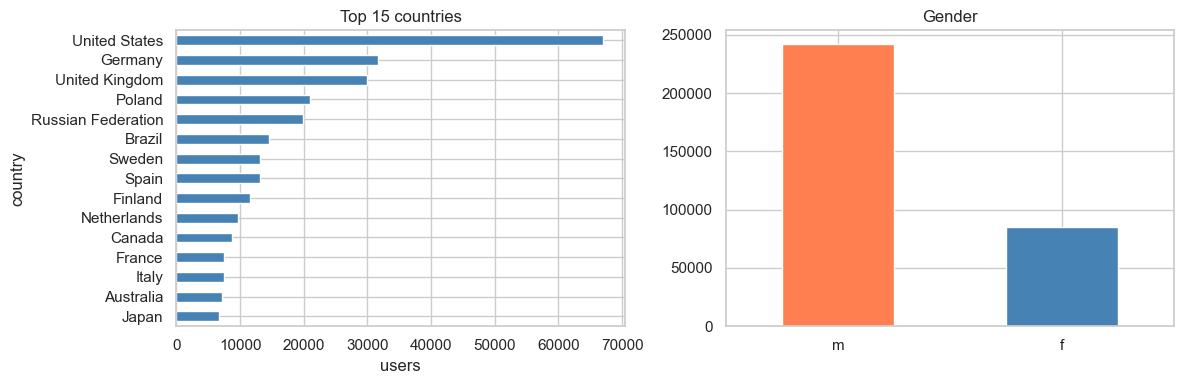

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

country_counts = profiles["country"].value_counts().head(15)
country_counts.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top 15 countries")
axes[0].set_xlabel("users")
axes[0].invert_yaxis()

profiles["gender"].value_counts().plot(kind="bar", ax=axes[1], color=["coral", "steelblue", "gray"])
axes[1].set_title("Gender")
axes[1].set_xlabel("")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

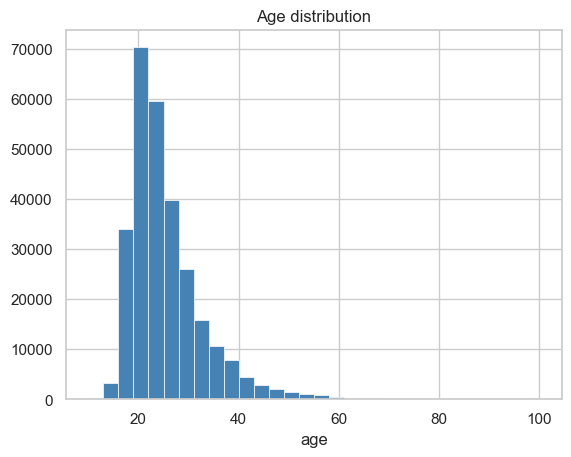

In [10]:
# Age distribution (drop missing)
age_clean = profiles["age"].dropna()
age_clean = pd.to_numeric(age_clean, errors="coerce").dropna()
age_clean = age_clean[(age_clean >= 10) & (age_clean <= 100)]
age_clean.hist(bins=30, edgecolor="white", linewidth=0.5, color="steelblue")
plt.title("Age distribution")
plt.xlabel("age")
plt.show()

## 7. Join: plays + profiles (optional)

In [11]:
# Merge to get country/gender for each play row (for deeper analysis)
merged = plays.merge(profiles[["user_sha1", "country", "gender"]], on="user_sha1", how="left")
merged.head()

,user_sha1,artist_mbid,artist_name,plays,country,gender
0,00000c289a1829a808ac09c00daf10bc3c4e223b,3bd73256-3905-4f3a-97e2-8b341527f805,betty blowtorch,2137,Germany,f
1,00000c289a1829a808ac09c00daf10bc3c4e223b,f2fb0ff0-5679-42ec-a55c-15109ce6e320,die Ärzte,1099,Germany,f
2,00000c289a1829a808ac09c00daf10bc3c4e223b,b3ae82c2-e60b-4551-a76d-6620f1b456aa,melissa etheridge,897,Germany,f
3,00000c289a1829a808ac09c00daf10bc3c4e223b,3d6bbeb7-f90e-4d10-b440-e153c0d10b53,elvenking,717,Germany,f
4,00000c289a1829a808ac09c00daf10bc3c4e223b,bbd2ffd7-17f4-4506-8572-c1ea58c3f9a8,juliette & the licks,706,Germany,f


In [12]:
# Example: top artists in a specific country (e.g. United States)
us = merged[merged["country"] == "United States"]
us.groupby("artist_name")["plays"].sum().sort_values(ascending=False).head(15)

artist_name
the beatles            327925
radiohead              252413
lil wayne              180122
death cab for cutie    158822
modest mouse           124802
bob dylan               99031
afi                     98190
elliott smith           93796
nine inch nails         86315
kanye west              85606
coldplay                84730
pink floyd              80952
sufjan stevens          79445
bright eyes             75827
iron & wine             73879
Name: plays, dtype: int64